# **OcuDetect AI / FundusGuard AI**

model p1 using ResNet-50

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

{}

In [1]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# **Collect Dataset 1**

In [2]:
!kaggle datasets download -d arnavjain1/glaucoma-datasets

!unzip glaucoma-datasets.zip -d glaucoma_dataset

Streaming output truncated to the last 5000 lines.
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0207.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0208.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0209.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0210.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0211.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0212.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0213.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0214.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0215.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0216.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0217.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0218.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0219.png  
  inflating: glaucoma_dataset/REFUGE/test/Masks_Cropped/T0220.png

**File structure:**

**Dataset 1 (arnavjain1/glaucoma-datasets):**

+ glaucoma_dataset
  + G1020
    + Images
      - image_0.jpg
      - image_0.json
      - image_1.jpg
      - image_1.json
      
      .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + NerveRemoved_Images
    - G1020.CSV
  + ORIGA
    + Images
        - image_0.jpg
        - image_0.json
        - image_1.jpg
        - image_1.json
        
        .....
    + Images_Cropped
    + Image_Square
    + Masks
    + Masks_Cropped
    + Mask_Square
    + Semi-automatic-annotations
    - OrigaList.CSV
  + REFUGE
  + MODELS
    - refug_clf.pkl
    - refuge_segmentation.pth



# **Preprocessing for Dataset 1**

In [3]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
from PIL import Image

In [4]:
SOURCE_PATH = "glaucoma_dataset"
DEST_PATH = "dataset"
ROI_DEST_PATH = "dataset/roi"

classes = ["glaucoma", "normal"]
splits = ["train", "val", "test"]

In [5]:
# consider the RGB image for dataset
def convert_to_jpg(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")
    dst_path = os.path.splitext(dst_path)[0] + ".jpg"
    img.save(dst_path, "JPEG", quality=95)

In [6]:
def process_dataset(source_folder, csv_file, output_root=DEST_PATH, roi_output_root=ROI_DEST_PATH):

    csv_path = os.path.join(source_folder, csv_file)
    df = pd.read_csv(csv_path)

    print("\nProcessing:", source_folder)

    if "G1020" in source_folder:
        image_col = "imageID"
        label_col = "binaryLabels"
        images_folder = os.path.join(source_folder, "Images")

        roi_folders = [
            os.path.join(source_folder, "Images_Cropped"),
            os.path.join(source_folder, "Images_Cropped", "img")
        ]

    elif "ORIGA" in source_folder:
        image_col = "Filename"
        label_col = "Glaucoma"
        images_folder = os.path.join(source_folder, "Images_Cropped")

        roi_folders = [
            os.path.join(source_folder, "Images_Cropped")
        ]

    else:
        raise ValueError("Unknown dataset")

    images = df[image_col].astype(str).str.strip().values
    labels = df[label_col].astype(int).values

    # I am Separate small classes (less than 2 samples)
    class_counts = Counter(labels)
    print("Class Distribution:", class_counts)

    valid_images = []
    valid_labels = []
    roi_paths = []

    # for img, lbl in zip(images, labels):
    #     img_path = os.path.join(images_folder, img)

    #     if os.path.exists(img_path):
    #         valid_images.append(img_path)
    #         valid_labels.append(lbl)

    extensions = [".jpg", ".jpeg", ".png", ".bmp"]

    for img, lbl in zip(images, labels):
        base_name = os.path.splitext(img)[0]
        full_path = None
        for ext in extensions:
            p = os.path.join(images_folder, base_name + ext)
            if os.path.exists(p):
                full_path = p
                break

        if full_path is None:
            print("Missing full:", img)
            continue

        roi_path = None
        for roi_folder in roi_folders:
            for ext in extensions:
                p = os.path.join(roi_folder, base_name + ext)
                if os.path.exists(p):
                    roi_path = p
                    break
            if roi_path:
                break

        valid_images.append(full_path)
        valid_labels.append(lbl)
        roi_paths.append(roi_path)  # may be None

    print("Valid images found:", len(valid_images))

    class_counts = Counter(valid_labels)
    small_classes = [cls for cls, count in class_counts.items() if count < 2]

    print("Small classes:", small_classes)

    train_imgs, train_lbls = [], []
    valid_imgs, valid_lbls = [], []

    for img, lbl in zip(valid_images, valid_labels):
        if lbl in small_classes:
            train_imgs.append(img)
            train_lbls.append(lbl)
        else:
            valid_imgs.append(img)
            valid_lbls.append(lbl)

    # Train (60%)
    X_train, X_temp, y_train, y_temp, roi_train, roi_temp = train_test_split(
        valid_images, valid_labels, roi_paths,
        test_size=0.4,
        stratify=valid_labels,
        random_state=42
    )

    # Validation (10%) and Test (30%)
    X_val, X_test, y_val, y_test, roi_val, roi_test = train_test_split(
        X_temp, y_temp, roi_temp,
        test_size=0.75,
        stratify=y_temp,
        random_state=42
    )

    # At last add small class samples fully to the train
    X_train += train_imgs
    y_train += train_lbls

    print(f"Train: {len(X_train)}")
    print(f"Validation: {len(X_val)}")
    print(f"Test: {len(X_test)}")

    for root in [output_root, roi_output_root]:
        for split in splits:
            for cls in classes:
                os.makedirs(os.path.join(root, split, cls), exist_ok=True)

    # just doing copy past samples (not touch the original)
    def copy_files(images, labels, roi_list, split_name):
        for img, lbl, roi_img in zip(images, labels, roi_list):
            class_name = "glaucoma" if lbl == 1 else "normal"

            dst = os.path.join(
                output_root,
                split_name,
                class_name,
                os.path.basename(img)
            )

            ext = os.path.splitext(img)[1].lower()

            if ext in [".jpg", ".jpeg"]:
                shutil.copy(img, dst)
            elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                convert_to_jpg(img, dst)

            if roi_img:
                dst_roi = os.path.join(
                    roi_output_root,
                    split_name,
                    class_name,
                    os.path.basename(img)
                )
                if ext in [".jpg", ".jpeg"]:
                  shutil.copy(img, dst_roi)
                elif ext in [".png", ".bmp", ".tiff"]: #changing it to RGB
                  convert_to_jpg(img, dst_roi)

    copy_files(X_train, y_train, roi_train, "train")
    copy_files(X_val, y_val, roi_val, "val")
    copy_files(X_test, y_test, roi_test, "test")

    print("Dataset prepared successfully!")

In [7]:
# process_dataset(
#     os.path.join(SOURCE_PATH, "G1020"),
#     "G1020.csv",
#     "Images_Cropped"
# )

# process_dataset(
#     os.path.join(SOURCE_PATH, "ORIGA"),
#     "OrigaList.csv",
#     "origa_info.csv"
#     "Images_Cropped"
# )

# print("Dataset split into Train, Test, Val successfully!")

process_dataset(
    os.path.join(SOURCE_PATH, "G1020"),
    "G1020.csv"
)

process_dataset(
    os.path.join(SOURCE_PATH, "ORIGA"),
    "OrigaList.csv"
)

print("Dataset split into Train, Test, Val successfully!")


Processing: glaucoma_dataset/G1020
Class Distribution: Counter({np.int64(0): 724, np.int64(1): 296})
Valid images found: 1020
Small classes: []
Train: 612
Validation: 102
Test: 306
Dataset prepared successfully!

Processing: glaucoma_dataset/ORIGA
Class Distribution: Counter({np.int64(0): 482, np.int64(1): 168})
Valid images found: 650
Small classes: []
Train: 390
Validation: 65
Test: 195
Dataset prepared successfully!
Dataset split into Train, Test, Val successfully!


Not need, so i delete this:
  + Images_Cropped/
  + origa_info.csvImages_Cropped/


In [ ]:
shutil.rmtree("Images_Cropped", ignore_errors=True)
shutil.rmtree("origa_info.csvImages_Cropped", ignore_errors=True)

**Download the Preprocessed Dataset**

In [ ]:
from google.colab import files

shutil.make_archive("dataset", 'zip', "dataset")

#files.download("dataset.zip")

'/content/dataset.zip'

# **Collect Dataset 2**

In [8]:
#https://www.kaggle.com/datasets/sshikamaru/glaucoma-detection

!kaggle datasets download -d sshikamaru/glaucoma-detection

!unzip glaucoma-detection.zip -d glaucoma-detection

Dataset URL: https://www.kaggle.com/datasets/sshikamaru/glaucoma-detection
License(s): CC0-1.0
100% 402M/402M [00:12<00:00, 34.9MB/s]

Archive:  glaucoma-detection.zip
  inflating: glaucoma-detection/ACRIMA/Images/Im001_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im002_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im003_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im004_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im005_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im006_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im007_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im008_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im009_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im010_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im011_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im012_ACRIMA.jpg  
  inflating: glaucoma-detection/ACRIMA/Images/Im013_

**File Structure:**

**Dataset 2 (sshikamaru/glaucoma-detection):**

  + glaucoma-detection/
    + ACRIMA/
      + Images/
        - Im001_ARIMA.jpg
        - Im002_ARIMA.jpg
        - Im003_ARIMA.jpg
        
        .....
    + Fundus_Train_Val_Data/
      + Fundus_Scanes_Sorted/
        + Train/
          + Glaucoma_Negative/
            - 001.jpg
            - 002.jpg
            - 003.jpg
            
            .....
          + Glaucoma_Positive/
            - 036.jpg
            - 041.jpg
            - 069.jpg
            
            .....
        + Validation/
          + Glaucoma_Negative/
            - 483.jpg
            - 488.jpg
            - 491.jpg
            
            ......
          + Glaucoma_Positive/
            - 600.jpg
            - 605.jpg
            - 609.jpg
            
            ......
    + ORIGA/
      + ORIGA/
        + Images/
          - 001.jpg
          - 002.jpg
          - 004.jpg
          
          .......
        + Semi-automatic-annotation/
          - 001.mat
          - 002.mat
          - 004.mat
          
          .......
        - OrigaList.mat
        - TestC2D.asv
        - TestC2D.m
        - readme.txt
    - glaucoma.csv
    

# **Create New Dataset** with 1 and 2

In [9]:
import os
import shutil
from pathlib import Path

dataset1_path = "dataset"
dataset2_path = "dataset_v2"

In [10]:
raw_glaucoma = os.path.join(dataset2_path, "raw", "glaucoma")
raw_normal = os.path.join(dataset2_path, "raw", "normal")

os.makedirs(raw_glaucoma, exist_ok=True)
os.makedirs(raw_normal, exist_ok=True)

g_count = 0
n_count = 0

for split in ["train", "val", "test"]:
    print(f"Work on {split} folder\n")
    glaucoma_path = os.path.join(dataset1_path, split, "glaucoma")
    normal_path = os.path.join(dataset1_path, split, "normal")

    if os.path.exists(glaucoma_path):
        for file in os.listdir(glaucoma_path):

            src = os.path.join(glaucoma_path, file)

            if os.path.isfile(src):

                new_name = f"d1_g_{g_count:05d}.jpg"
                dst = os.path.join(raw_glaucoma, new_name)

                shutil.copy(src, dst)
                g_count += 1

    # Copy with rename to avoid collition
    if os.path.exists(normal_path):
        for file in os.listdir(normal_path):

            src = os.path.join(normal_path, file)

            if os.path.isfile(src):

                new_name = f"d1_n_{n_count:05d}.jpg"
                dst = os.path.join(raw_normal, new_name)

                shutil.copy(src, dst)
                n_count += 1


print("Dataset-1 extraction complete!")
print("Glaucoma images:", g_count)
print("Normal images:", n_count)

Work on train folder

Work on val folder

Work on test folder

Dataset-1 extraction complete!
Glaucoma images: 464
Normal images: 1206


# **Collect raw images from Dataset 2** in labeled folder / **Preprocessing for Dataset 2**

In [11]:
import os
import shutil
import pandas as pd


dataset2_root = "glaucoma-detection"

fundus_root = os.path.join(dataset2_root,
                           "Fundus_Train_Val_Data",
                           "Fundus_Scanes_Sorted")

origa_images = os.path.join(dataset2_root,
                            "ORIGA",
                            "ORIGA",
                            "Images")

csv_path = os.path.join(dataset2_root, "glaucoma.csv")


helper_root = "data_helper"

In [12]:
glaucoma_dir = os.path.join(helper_root, "glaucoma")
normal_dir = os.path.join(helper_root, "normal")

# TEMP folder (important for 1:1)
temp_normal_dir = "temp_normal"

os.makedirs(glaucoma_dir, exist_ok=True)
os.makedirs(normal_dir, exist_ok=True)
os.makedirs(temp_normal_dir, exist_ok=True)

g_count = 0
n_count = 0

temp_count = 0

NEEDED_NORMAL = 237

for split in ["Train", "Validation"]:

    print(f"Work on {split} folder\n")
    pos_path = os.path.join(fundus_root, split, "Glaucoma_Positive")
    neg_path = os.path.join(fundus_root, split, "Glaucoma_Negative")

    # glaucoma images
    if os.path.exists(pos_path):
        for img in os.listdir(pos_path):

            src = os.path.join(pos_path, img)

            if os.path.isfile(src):

                new_name = f"d2_fundus_g_{g_count:05d}.jpg"
                dst = os.path.join(glaucoma_dir, new_name)

                shutil.copy(src, dst)
                g_count += 1

    # normal images
    if os.path.exists(neg_path):
        for img in os.listdir(neg_path):

            src = os.path.join(neg_path, img)

            if os.path.isfile(src):

                new_name = f"d2_fundus_n_{n_count:05d}.jpg"
                dst = os.path.join(normal_dir, new_name)

                shutil.copy(src, dst)
                n_count += 1

                # I am Save some sample to temp (only first 237)
                if temp_count < NEEDED_NORMAL:
                    temp_name = f"d2_fundus_n_{temp_count:05d}.jpg"
                    temp_dst = os.path.join(temp_normal_dir, temp_name)
                    shutil.copy(src, temp_dst)
                    temp_count += 1

                n_count += 1

df = pd.read_csv(csv_path)

for i, row in df.iterrows():

    filename = row["Filename"]
    label = row["Glaucoma"]

    src = os.path.join(origa_images, filename)

    if not os.path.exists(src):
        continue

    if label == 1:
        new_name = f"d2_origa_g_{g_count:05d}.jpg"
        dst = os.path.join(glaucoma_dir, new_name)
        shutil.copy(src, dst)
        g_count += 1

    else:
        new_name = f"d2_origa_n_{n_count:05d}.jpg"
        dst = os.path.join(normal_dir, new_name)
        shutil.copy(src, dst)
        n_count += 1

print("Extraction Complete!\n")

print("Glaucoma images collected:", g_count)
print("Normal images collected:", n_count)
print("Temp Normal Saved:", temp_count)

print("\nSaved inside:")
print(helper_root)

'''
Previous
--------------------------------------
Work on Train folder

Work on Validation folder

Extraction Complete!

Glaucoma images collected: 336
Normal images collected: 485

Saved inside:
data_helper
'''

Work on Train folder

Work on Validation folder

Extraction Complete!

Glaucoma images collected: 336
Normal images collected: 1446
Temp Normal Saved: 237

Saved inside:
data_helper


'\nPrevious\n--------------------------------------\nWork on Train folder\n\nWork on Validation folder\n\nExtraction Complete!\n\nGlaucoma images collected: 336\nNormal images collected: 485\n\nSaved inside:\ndata_helper\n'

In [13]:
# Delete normal images from data_helper to make it 1:1

normal_dir = "data_helper/normal"

files = os.listdir(normal_dir)

print("Normal images before deletion:", len(files))

for f in files:
    path = os.path.join(normal_dir, f)

    if os.path.isfile(path):
        os.remove(path)

print("Normal images after deletion:", len(os.listdir(normal_dir)))

Normal images before deletion: 964
Normal images after deletion: 0


# **Merge both dataset into dataset_v2**

In [14]:
helper_root = "data_helper"
dataset_v2_root = "dataset_v2/raw"

helper_glaucoma = os.path.join(helper_root, "glaucoma")
helper_normal = os.path.join(helper_root, "normal")

dest_glaucoma = os.path.join(dataset_v2_root, "glaucoma")
dest_normal = os.path.join(dataset_v2_root, "normal")

os.makedirs(dest_glaucoma, exist_ok=True)
os.makedirs(dest_normal, exist_ok=True)


In [15]:
g_count = len(os.listdir(dest_glaucoma))
n_count = len(os.listdir(dest_normal))


for img in os.listdir(helper_glaucoma):
    src = os.path.join(helper_glaucoma, img)
    if os.path.isfile(src):
        new_name = f"d2_g_{g_count:05d}.jpg"
        dst = os.path.join(dest_glaucoma, new_name)

        shutil.copy(src, dst)

        g_count += 1

for img in os.listdir(helper_normal):
    src = os.path.join(helper_normal, img)
    if os.path.isfile(src):
        new_name = f"d2_n_{n_count:05d}.jpg"
        dst = os.path.join(dest_normal, new_name)

        shutil.copy(src, dst)

        n_count += 1

print("Merge Complete!\n")

print("Total glaucoma images now:", len(os.listdir(dest_glaucoma)))
print("Total normal images now:", len(os.listdir(dest_normal)))

Merge Complete!

Total glaucoma images now: 800
Total normal images now: 1206


**ROI Samples transfer**

In [ ]:
dataset_root = "dataset"
old_roi_root = "dataset/roi"
new_roi_root = "dataset_v2/roi"

splits = ["train", "val", "test"]
classes = ["glaucoma", "normal"]

for split in splits:
    for cls in classes:

        src_img_dir = os.path.join(dataset_v2_root, split, cls)
        dst_roi_dir = os.path.join(new_roi_root, split, cls)

        os.makedirs(dst_roi_dir, exist_ok=True)

        for img_name in os.listdir(src_img_dir):

            # remove augmentation prefix if exists
            base_name = img_name

            if img_name.startswith("aug_"):
                parts = img_name.split("_", 2)
                if len(parts) == 3:
                    base_name = parts[2]

            # search original ROI
            src_roi = os.path.join(old_roi_root, cls, base_name)

            if not os.path.exists(src_roi):
                continue

            dst_roi = os.path.join(dst_roi_dir, img_name)

            shutil.copy(src_roi, dst_roi)

print("ROI files copied and renamed successfully.")

# **Data Spliting into Train, Test, Val**

In [16]:
import os
import shutil
from collections import Counter
from sklearn.model_selection import train_test_split
from PIL import Image

In [17]:
raw_root = "dataset_v2/raw"
roi_root = "dataset/roi"   # my old ROI dataset

output_root = "dataset_v2"
roi_output_root = "dataset_v2/roi"

classes = ["glaucoma", "normal"]
splits = ["train", "val", "test"]

valid_images = []
valid_labels = []
roi_paths = []

In [18]:
for cls in classes:
    class_path = os.path.join(raw_root, cls)
    for img in os.listdir(class_path):
        img_path = os.path.join(class_path, img)

        if not img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tiff")):
            continue

        valid_images.append(img_path)

        if cls == "glaucoma":
            valid_labels.append(1)
        else:
            valid_labels.append(0)

        roi_img = os.path.join(roi_root, cls, img)

        if os.path.exists(roi_img):
            roi_paths.append(roi_img)
        else:
            roi_paths.append(None)


print("Total images:", len(valid_images))


class_counts = Counter(valid_labels)

small_classes = [cls for cls, count in class_counts.items() if count < 2]

print("Small classes:", small_classes)

train_imgs, train_lbls = [], []
valid_imgs, valid_lbls = [], []

for img, lbl in zip(valid_images, valid_labels):

    if lbl in small_classes:
        train_imgs.append(img)
        train_lbls.append(lbl)
    else:
        valid_imgs.append(img)
        valid_lbls.append(lbl)

X_train, X_temp, y_train, y_temp, roi_train, roi_temp = train_test_split(
    valid_images,
    valid_labels,
    roi_paths,
    test_size=0.4,
    stratify=valid_labels,
    random_state=42
)


X_val, X_test, y_val, y_test, roi_val, roi_test = train_test_split(
    X_temp,
    y_temp,
    roi_temp,
    test_size=0.75,
    stratify=y_temp,
    random_state=42
)

X_train += train_imgs
y_train += train_lbls

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

for root in [output_root, roi_output_root]:
    for split in splits:
        for cls in classes:
            os.makedirs(
                os.path.join(root, split, cls),
                exist_ok=True
            )


def convert_to_jpg(src, dst):
    img = Image.open(src).convert("RGB")
    dst = os.path.splitext(dst)[0] + ".jpg"
    img.save(dst, "JPEG", quality=95)


def copy_files(images, labels, roi_list, split_name):
    for img, lbl, roi_img in zip(images, labels, roi_list):
        class_name = "glaucoma" if lbl == 1 else "normal"
        dst = os.path.join(
            output_root,
            split_name,
            class_name,
            os.path.basename(img)
        )

        ext = os.path.splitext(img)[1].lower()

        if ext in [".jpg", ".jpeg"]:
            shutil.copy(img, dst)

        elif ext in [".png", ".bmp", ".tiff"]:
            convert_to_jpg(img, dst)

        if roi_img:

            dst_roi = os.path.join(
                roi_output_root,
                split_name,
                class_name,
                os.path.basename(img)
            )

            if ext in [".jpg", ".jpeg"]:
                shutil.copy(roi_img, dst_roi)

            elif ext in [".png", ".bmp", ".tiff"]:
                convert_to_jpg(roi_img, dst_roi)


copy_files(X_train, y_train, roi_train, "train")
copy_files(X_val, y_val, roi_val, "val")
copy_files(X_test, y_test, roi_test, "test")

print("Dataset prepared successfully!")

Total images: 2006
Small classes: []
Train: 1203
Validation: 200
Test: 603
Dataset prepared successfully!


**Copy First 237 Normal Images for 1:1 samples**
```
before augment
glaucoma = 480
normal   = 723 -> 960   # balanced for augmentation

after augment
glaucoma = 480 * 4 = 1920
normal   = 960 * 2 = 1920   # PERFECT 1:1
```

In [19]:
temp_folder = "temp_normal"
target_folder = "dataset_v2/train/normal"

os.makedirs(target_folder, exist_ok=True)

files = sorted(os.listdir(temp_folder))

existing_count = len(os.listdir(target_folder))

# copy temp file to dataset_v2
for i, img in enumerate(files):
    src = os.path.join(temp_folder, img)
    if not os.path.isfile(src):
        continue

    new_name = f"extra_n_{existing_count + i:05d}.jpg"
    dst = os.path.join(target_folder, new_name)
    shutil.copy(src, dst)

print("Temp images added:", len(files))
print("New total normal images:", len(os.listdir(target_folder)))

Temp images added: 237
New total normal images: 960


In [20]:
# Sample size
# expected: Train normal: 960 , Train glaucoma: 480
print("Train glaucoma:", len(os.listdir("dataset_v2/train/glaucoma")))
print("Train normal:", len(os.listdir("dataset_v2/train/normal")))

Train glaucoma: 480
Train normal: 960


# **Data Augmentaion for Variation**

In [21]:
import os
import random
from PIL import Image, ImageEnhance, ImageOps
import numpy as np

In [22]:
# augment iin only train/ folder
# DATASET_PATH = "dataset/train"
# ROI_PATH = "dataset/roi/train"

DATASET_PATH = "dataset_v2/train"
ROI_PATH = "dataset_v2/roi/train"

In [23]:
def rotate(img):
    return img.rotate(random.choice([90, 180, 270]))

def flip(img):
    if random.random() > 0.5:
        return ImageOps.mirror(img)   # horizontal flip
    else:
        return ImageOps.flip(img)     # vertical flip

def brightness(img):
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def contrast(img):
    enhancer = ImageEnhance.Contrast(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def color(img):
    enhancer = ImageEnhance.Color(img)
    return enhancer.enhance(random.uniform(0.7, 1.3))

def add_noise(img):
    arr = np.array(img)
    noise = np.random.randint(0, 30, arr.shape, dtype='uint8')
    arr = np.clip(arr + noise, 0, 255)
    return Image.fromarray(arr)

augmentations = [rotate, flip, brightness, contrast, color, add_noise]


In [24]:
# def augment_dataset():
#     print("Augmenting start...")
#     for class_name in ["glaucoma", "normal"]:
#         class_path = os.path.join(DATASET_PATH, class_name)
#         print(f"Work on: {class_path}")

#         for img_name in os.listdir(class_path):
#             img_path = os.path.join(class_path, img_name)

#             if not img_name.lower().endswith(".jpg"):
#                 continue

#             img = Image.open(img_path).convert("RGB")

#             # i create 3 augmented copies per image
#             for i in range(3):
#                 aug_img = img.copy()

#                 # apply any 2 random augmentations
#                 for aug in random.sample(augmentations, 2):
#                     aug_img = aug(aug_img)

#                 new_name = f"aug_{i}_{img_name}"
#                 save_path = os.path.join(class_path, new_name)

#                 aug_img.save(save_path, "JPEG", quality=95)

#     print("Augmentation completed successfully!")

# augment_dataset()

## Class Balancing via Targeted Augmentation
def augment_dataset():
    print("Augmenting start...")
    for class_name in ["glaucoma", "normal"]:
        class_path = os.path.join(DATASET_PATH, class_name)
        roi_class_path = os.path.join(ROI_PATH, class_name)

        print(f"\nWork on: {class_path}\n")

        if class_name == "glaucoma":
            num_copies = 3   # MORE copies
        else:
            num_copies = 1   # LESS copies

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            # roi_img_path = os.path.join(roi_class_path, img_name)

            print(f"aug: {img_path}")

            if not img_name.lower().endswith(".jpg"):
                continue

            # if not os.path.exists(roi_img_path):
            #     print("ROI missing:", img_name)
            #     continue

            img = Image.open(img_path).convert("RGB")
            # roi_img = Image.open(roi_img_path).convert("RGB")

            for i in range(num_copies):
                aug_img = img.copy()
                # aug_roi = roi_img.copy()

                # SAME augmentations applied to both
                chosen_augs = random.sample(augmentations, 2)

                # apply any 2 random augmentations
                for aug in chosen_augs:
                    aug_img = aug(aug_img)
                    # aug_roi = aug(aug_roi)

                new_name = f"aug_{i}_{img_name}"

                save_full = os.path.join(class_path, new_name)
                save_roi = os.path.join(roi_class_path, new_name)

                aug_img.save(save_full, "JPEG", quality=95)
                # aug_roi.save(save_roi, "JPEG", quality=95)

    print("Augmentation completed successfully!")

augment_dataset()

Augmenting start...

Work on: dataset_v2/train/glaucoma

aug: dataset_v2/train/glaucoma/d1_g_00286.jpg
aug: dataset_v2/train/glaucoma/d2_g_00466.jpg
aug: dataset_v2/train/glaucoma/d2_g_00716.jpg
aug: dataset_v2/train/glaucoma/d1_g_00393.jpg
aug: dataset_v2/train/glaucoma/d2_g_00569.jpg
aug: dataset_v2/train/glaucoma/d1_g_00292.jpg
aug: dataset_v2/train/glaucoma/d1_g_00180.jpg
aug: dataset_v2/train/glaucoma/d2_g_00631.jpg
aug: dataset_v2/train/glaucoma/d2_g_00628.jpg
aug: dataset_v2/train/glaucoma/d2_g_00744.jpg
aug: dataset_v2/train/glaucoma/d1_g_00037.jpg
aug: dataset_v2/train/glaucoma/d1_g_00087.jpg
aug: dataset_v2/train/glaucoma/d1_g_00044.jpg
aug: dataset_v2/train/glaucoma/d1_g_00447.jpg
aug: dataset_v2/train/glaucoma/d2_g_00493.jpg
aug: dataset_v2/train/glaucoma/d1_g_00092.jpg
aug: dataset_v2/train/glaucoma/d1_g_00085.jpg
aug: dataset_v2/train/glaucoma/d2_g_00613.jpg
aug: dataset_v2/train/glaucoma/d1_g_00329.jpg
aug: dataset_v2/train/glaucoma/d2_g_00670.jpg
aug: dataset_v2/train/g

# **Data Distribution**

In [25]:
import os
import matplotlib.pyplot as plt

In [27]:
DATASET_PATH = "dataset_v2"

splits = ["train", "val", "test"]
classes = ["glaucoma", "normal"]

labels = []
counts = []

for split in splits:
    for cls in classes:
        path = os.path.join(DATASET_PATH, split, cls)

        num_images = len([
            f for f in os.listdir(path)
            if f.lower().endswith(".jpg")
        ])

        labels.append(f"{split}/{cls}")
        counts.append(num_images)

print(f"labels: {labels},\nCounts: {counts}")

short_labels = ["Tr-G", "Tr-N", "Va-G", "Va-N", "Te-G", "Te-N"]


labels: ['train/glaucoma', 'train/normal', 'val/glaucoma', 'val/normal', 'test/glaucoma', 'test/normal'],
Counts: [1920, 1920, 80, 120, 240, 363]


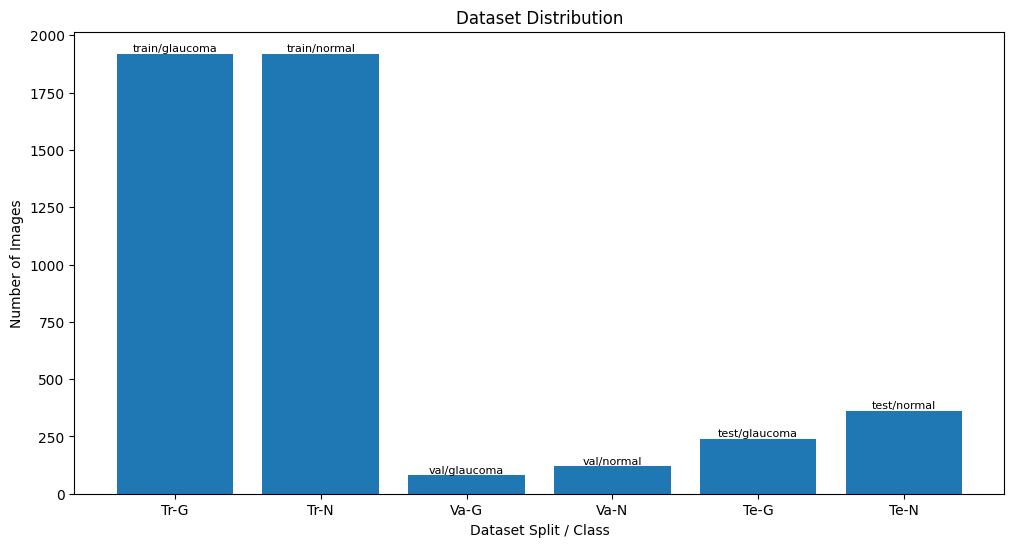

In [28]:
plt.figure(figsize=(12,6))

plt.bar(short_labels, counts)

plt.xlabel("Dataset Split / Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")

for i, txt in enumerate(labels):
    plt.text(i, counts[i], txt, ha='center', va='bottom', fontsize=8)

plt.show()

**Download the Augmentated Dataset**

In [ ]:
from google.colab import files

shutil.make_archive("train", 'zip', "dataset/train")

files.download("train.zip")

KeyboardInterrupt: 

In [ ]:
shutil.make_archive("test", 'zip', "dataset/test")

files.download("test.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
shutil.make_archive("val", 'zip', "dataset/val")

files.download("val.zip")

'/content/val.zip'

In [ ]:
shutil.make_archive("roi", 'zip', "dataset/roi")

files.download("roi.zip")

'/content/roi.zip'

In [ ]:
!du -sh roi.zip

2.9G	roi.zip


**Prune Un-necessary files from temp state**

In [ ]:
!rm train.zip
!rm test.zip
!rm val.zip
!rm roi.zip

In [29]:
!rm -rf data_helper/
!rm -rf dataset/
!rm -rf glaucoma-detection/
!rm -rf glaucoma_dataset/
!rm -rf temp_normal/
!rm test.zip
!rm train.zip
!rm val.zip

rm: cannot remove 'test.zip': No such file or directory
rm: cannot remove 'train.zip': No such file or directory
rm: cannot remove 'val.zip': No such file or directory


# **Define the ResNet50 Architecture**

# Why ResNet-50 Is Good for My Project

I am using:
* Fundus eye images
* Binary classification (glaucoma vs normal)
* Small/medium dataset

ResNet-50 works well because:

1. Pretrained features already know edges, textures, shapes

2. Deep enough to capture optic disc patterns

3. Transfer learning works well for medical images as my past expriments

So using **ImageNet pretrained ResNet‑50** is a good choice for this.

# Architecture

The model structure looks like this:

```
Input Image (224*224*3)
      ↓
Initial Convolution Layer
      ↓
Max Pooling
      ↓
Residual Block Group 1
      ↓
Residual Block Group 2
      ↓
Residual Block Group 3
      ↓
Residual Block Group 4
      ↓
Global Average Pooling
      ↓
Fully Connected Layer
      ↓
Softmax / Sigmoid Output
```

binary output project:

```
Output = Glaucoma / Normal as 1 / 0
```



## Input Layer

Input image size:

```
225 * 224 * 3
```

3 channels = RGB.

Your fundus image is resized to this.


# Residual Block Groups

ResNet-50 has 4 main stages.

| Stage   | Output Size | Blocks   | What it learns      |
| ------- | ----------- | -------- | ------------------- |
| Stage 1 | 56*56       | 3 blocks | edges, colors       |
| Stage 2 | 28*28       | 4 blocks | shapes, vessels     |
| Stage 3 | 14*14       | 6 blocks | optic disc patterns |
| Stage 4 | 7*7         | 3 blocks | glaucoma indicators |

Total = 16 residual blocks

Each block has 3 convolution layers.
- 49 convolution layers
- 1 fully connected layer


# **Deploy ResNet-50**

In [30]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchsummary import summary

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device) #ensure i am in colab

Using device: cuda


In [32]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [33]:
DATASET_PATH = "dataset_v2"

train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=val_test_transforms
)

In [34]:
class_names = train_dataset.classes
print("Classes:", class_names) # i am expecting ['normal', 'glaucoma'] only

Classes: ['glaucoma', 'normal']


In [35]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [36]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels = [label for _, label in train_dataset]

# adding class weights, because my dataset is not balanced
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)

Class Weights: tensor([1., 1.], device='cuda:0')


**Load the ResNet-50 from torch directly**

In [37]:
model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


In [38]:
# Freeze early layers for transfer learning

for param in model.parameters():
    param.requires_grad = False

# Unfreeze Layer4
# for param in model.layer4.parameters():
#     param.requires_grad = True

# Unfreeze the last block of Layer4 only
for param in model.layer4[-1].parameters():
    param.requires_grad = True

We know that ResNet50 output = 1000 classes.

but i change it to 2 classes (glaucoma / normal).

In [39]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.7), #0.5 to 0.7 for not remember, pattern find
    nn.Linear(256, 2)
)

In [40]:
model = model.to(device)

In [41]:
print("\nModel Architecture Summary:\n")

summary(model, (3, 224, 224))


Model Architecture Summary:

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      Bat

In [42]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-4   # i add here L2 regularization for overcome the underfitting of my model
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=3,
    # verbose=True
)

In [43]:
EPOCHS = 20

In [44]:
# i need this for later to make graphs and matrix
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float('inf')
patience = 5
counter = 0

# **Training Phase**

In [45]:
print("Training start...\n")

for epoch in range(EPOCHS):
    print(f"Epoch: {epoch+1} running..\n")
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}", end=" ")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}", end=" | ")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}", end="\n\n")
    scheduler.step(val_loss)

    # (Early Stopping + Best Model Saving) for reduce overfitting if
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        model_path = f"gla_p1_{int(val_acc * 100)}.pth"
        torch.save(model.state_dict(), model_path)
        print(f"Best model saved: {model_path}\n")
    else:
        counter += 1
        if counter >= patience:
            print("\n>> Early stopping triggered\n")
            break

Training start...

Epoch: 1 running..

Epoch 1/20 Train Loss: 0.6662 | Train Acc: 0.5904 | Val Loss: 0.6418 | Val Acc: 0.5550

Best model saved: gla_p1_55.pth

Epoch: 2 running..

Epoch 2/20 Train Loss: 0.6249 | Train Acc: 0.6331 | Val Loss: 0.6056 | Val Acc: 0.6350

Best model saved: gla_p1_63.pth

Epoch: 3 running..

Epoch 3/20 Train Loss: 0.6049 | Train Acc: 0.6622 | Val Loss: 0.5784 | Val Acc: 0.6450

Best model saved: gla_p1_64.pth

Epoch: 4 running..

Epoch 4/20 Train Loss: 0.5846 | Train Acc: 0.6789 | Val Loss: 0.5332 | Val Acc: 0.7550

Best model saved: gla_p1_75.pth

Epoch: 5 running..

Epoch 5/20 Train Loss: 0.5668 | Train Acc: 0.7008 | Val Loss: 0.5441 | Val Acc: 0.7350

Epoch: 6 running..

Epoch 6/20 Train Loss: 0.5578 | Train Acc: 0.7070 | Val Loss: 0.5534 | Val Acc: 0.7100

Epoch: 7 running..

Epoch 7/20 Train Loss: 0.5374 | Train Acc: 0.7130 | Val Loss: 0.5784 | Val Acc: 0.6600

Epoch: 8 running..

Epoch 8/20 Train Loss: 0.5442 | Train Acc: 0.7232 | Val Loss: 0.5779 | Va

# **Testing Phase**

In [46]:
model.eval()

all_preds = []
all_labels = []

print("Testing start..\n\n")
with torch.no_grad():

    for images, labels in test_loader:
        print(f"Testing for {labels}")

        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

Testing start..


Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
Testing for tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1

# **Save Model**

In [ ]:
torch.save(model.state_dict(), "gla_p1_75.pth")

In [47]:
!du -sh gla_p1_75.pth

92M	gla_p1_75.pth


# **Model Training Graph**

In [48]:
train_losses.append(train_loss)
val_losses.append(val_loss)

train_accuracies.append(train_acc)
val_accuracies.append(val_acc)

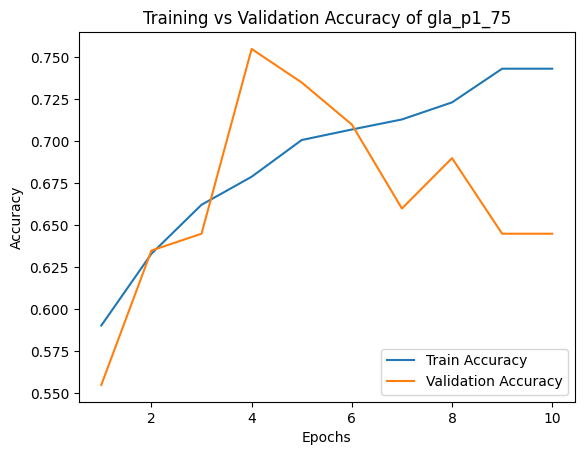

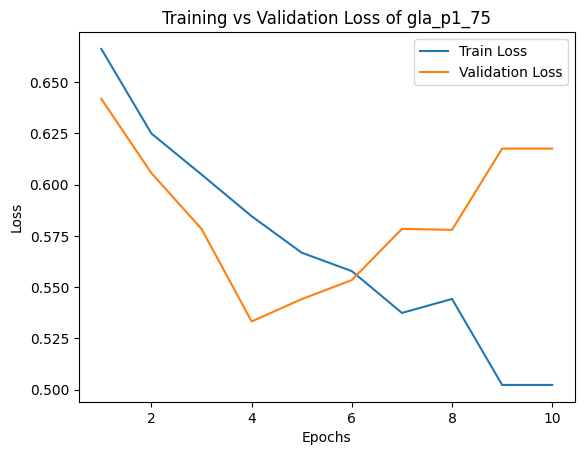

In [49]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy of gla_p1_75')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss of gla_p1_75')
plt.legend()
plt.show()


**Confusion Matrix**

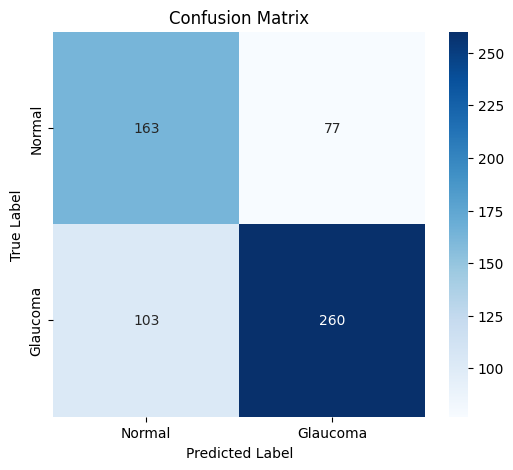

In [50]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

class_names = ["Normal", "Glaucoma"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [51]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

      Normal       0.61      0.68      0.64       240
    Glaucoma       0.77      0.72      0.74       363

    accuracy                           0.70       603
   macro avg       0.69      0.70      0.69       603
weighted avg       0.71      0.70      0.70       603

